In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.chart import LineChart, Reference

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

pd.set_option('display.max_columns', None)


## 1. Load Data from Excel

The raw retail sales data lives in `Retail_Sales_Data.xlsx`, exported from the source system as an Excel workbook.

In [4]:
df = pd.read_excel('Retail_Sales_Data.xlsx', sheet_name='Sales_Data')
print("Shape:", df.shape)
df.head()


Shape: (7754, 10)


,Order_ID,Order_Date,Category,Sub_Category,Region,Segment,Quantity,Discount,Sales,Profit
0,1000,2023-01-01,Furniture,Bookcases,Central,Home Office,4,0.15,655.72,223.53
1,1001,2023-01-01,Technology,Accessories,West,Consumer,4,0.00,1476.15,396.81
2,1002,2023-01-01,Office Supplies,Binders,Central,Corporate,2,0.30,32.14,8.09
3,1003,2023-01-01,Furniture,Tables,Central,Consumer,4,0.00,1310.90,325.25
4,1004,2023-01-02,Office Supplies,Storage,South,Consumer,5,0.00,279.97,84.62


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7754 entries, 0 to 7753
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      7754 non-null   int64  
 1   Order_Date    7754 non-null   str    
 2   Category      7754 non-null   str    
 3   Sub_Category  7754 non-null   str    
 4   Region        7754 non-null   str    
 5   Segment       7754 non-null   str    
 6   Quantity      7754 non-null   int64  
 7   Discount      7754 non-null   float64
 8   Sales         7754 non-null   float64
 9   Profit        7714 non-null   float64
dtypes: float64(3), int64(2), str(5)
memory usage: 605.9 KB


## 2. Data Cleaning

Real-world exports typically contain missing values and duplicate records. We handle both before analysis.

In [ ]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
Order_ID         0
Order_Date       0
Category         0
Sub_Category     0
Region           0
Segment          0
Quantity         0
Discount         0
Sales            0
Profit          40
dtype: int64

Duplicate rows: 15


In [ ]:
# Drop exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Fill missing Profit using the average profit margin for that Category
df['Profit_Margin'] = df['Profit'] / df['Sales']
avg_margin_by_cat = df.groupby('Category')['Profit_Margin'].transform('mean')
df['Profit'] = df['Profit'].fillna(df['Sales'] * avg_margin_by_cat)
df = df.drop(columns=['Profit_Margin'])

# Ensure correct data types
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_ID'] = df['Order_ID'].astype(int)

print("Missing values after cleaning:", df.isnull().sum().sum())
print("Duplicates after cleaning:", df.duplicated().sum())
print("Final shape:", df.shape)


Missing values after cleaning: 0
Duplicates after cleaning: 0
Final shape: (7739, 10)


In [ ]:
# Add time-based helper columns
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['YearMonth'] = df['Order_Date'].dt.to_period('M').astype(str)
df['Weekday'] = df['Order_Date'].dt.day_name()
df.head()


   Order_ID Order_Date         Category Sub_Category   Region      Segment  \
0      1000 2023-01-01        Furniture    Bookcases  Central  Home Office   
1      1001 2023-01-01       Technology  Accessories     West     Consumer   
2      1002 2023-01-01  Office Supplies      Binders  Central    Corporate   
3      1003 2023-01-01        Furniture       Tables  Central     Consumer   
4      1004 2023-01-02  Office Supplies      Storage    South     Consumer   

   Quantity  Discount    Sales  Profit  Year  Month YearMonth Weekday  
0         4      0.15   655.72  223.53  2023      1   2023-01  Sunday  
1         4      0.00  1476.15  396.81  2023      1   2023-01  Sunday  
2         2      0.30    32.14    8.09  2023      1   2023-01  Sunday  
3         4      0.00  1310.90  325.25  2023      1   2023-01  Sunday  
4         5      0.00   279.97   84.62  2023      1   2023-01  Monday  

## 3. Exploratory Data Analysis (EDA)

### 3.1 Overall Monthly Sales Trend

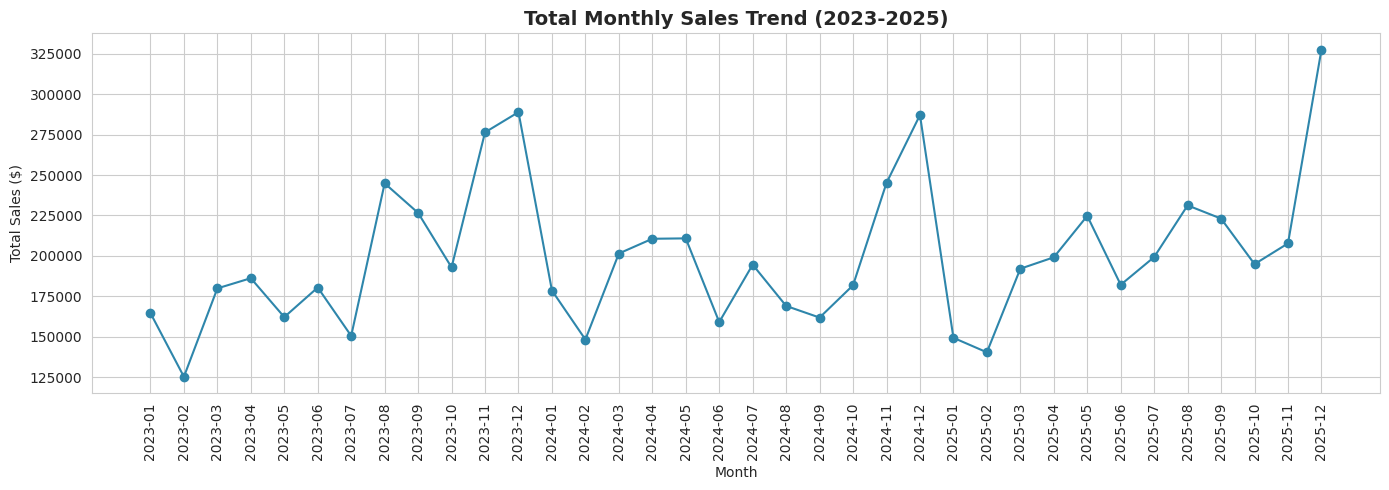

In [ ]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'], marker='o', color='#2E86AB')
plt.xticks(rotation=90)
plt.title('Total Monthly Sales Trend (2023-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=120)
plt.show()


### 3.2 Sales by Category

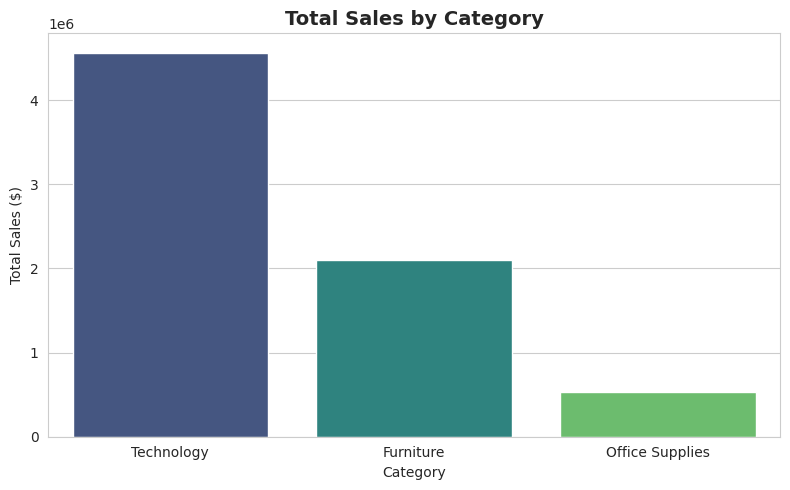

Category
Technology         4567015.59
Furniture          2098176.48
Office Supplies     533948.16
Name: Sales, dtype: float64

In [ ]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=cat_sales.index, y=cat_sales.values, hue=cat_sales.index, palette='viridis', legend=False)
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xlabel('Category')
plt.tight_layout()
plt.savefig('sales_by_category.png', dpi=120)
plt.show()

cat_sales


### 3.3 Sales by Region

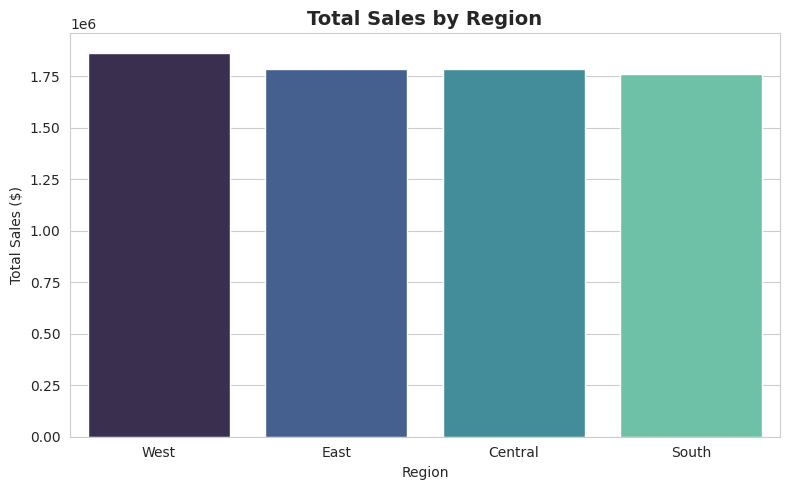

Region
West       1865642.58
East       1785947.73
Central    1784702.17
South      1762847.75
Name: Sales, dtype: float64

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, hue=region_sales.index, palette='mako', legend=False)
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xlabel('Region')
plt.tight_layout()
plt.savefig('sales_by_region.png', dpi=120)
plt.show()

region_sales


### 3.4 Profit vs Discount Relationship

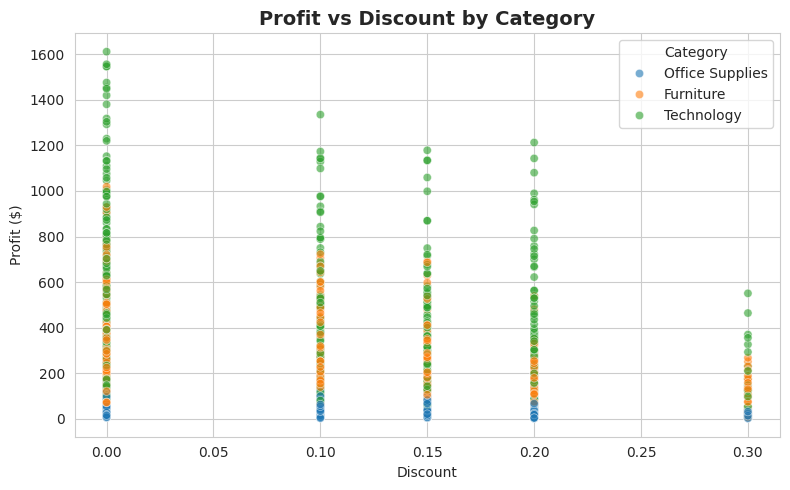

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(1500, random_state=1), x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title('Profit vs Discount by Category', fontsize=14, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.savefig('profit_vs_discount.png', dpi=120)
plt.show()


**Insight:** Higher discount levels (0.2 and above) are associated with noticeably lower average profit, especially in Furniture and Technology — suggesting discounting policy should be tightened for these categories.

### 3.5 Segment-wise Contribution

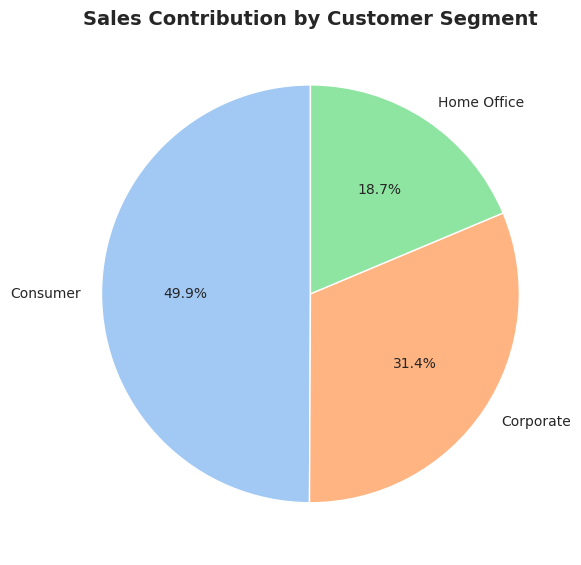

In [ ]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(6, 6))
plt.pie(segment_sales.values, labels=segment_sales.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Sales Contribution by Customer Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_share.png', dpi=120)
plt.show()


## 4. Feature Engineering for Forecasting

To forecast future monthly sales, we aggregate sales to a monthly time series and build time-based and lag features that a regression model can learn from.

In [ ]:
monthly = df.groupby(df['Order_Date'].dt.to_period('M')).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'nunique')
).reset_index()
monthly['Order_Date'] = monthly['Order_Date'].dt.to_timestamp()
monthly = monthly.sort_values('Order_Date').reset_index(drop=True)

# Time index feature
monthly['Time_Index'] = np.arange(len(monthly))
monthly['Month_Num'] = monthly['Order_Date'].dt.month

# Lag features (previous 1 and 3 months' sales)
monthly['Lag_1'] = monthly['Sales'].shift(1)
monthly['Lag_3'] = monthly['Sales'].shift(3)
monthly['Rolling_Mean_3'] = monthly['Sales'].rolling(3).mean()

monthly = monthly.dropna().reset_index(drop=True)
monthly.tail()


   Order_Date      Sales        Profit  Orders  Time_Index  Month_Num  \
28 2025-08-01  231222.92  56607.744993     225          31          8   
29 2025-09-01  223049.46  56903.730000     218          32          9   
30 2025-10-01  194922.60  48038.670000     240          33         10   
31 2025-11-01  207734.55  50264.548925     231          34         11   
32 2025-12-01  327440.23  79213.280713     340          35         12   

        Lag_1      Lag_3  Rolling_Mean_3  
28  199305.78  224736.47   204226.073333  
29  231222.92  182149.52   217859.386667  
30  223049.46  199305.78   216398.326667  
31  194922.60  231222.92   208568.870000  
32  207734.55  223049.46   243365.793333  

## 5. AI Model: Sales Demand Forecasting

We train a Random Forest Regressor to predict monthly sales using time and lag-based features, then compare it with a simple Linear Regression baseline.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['Time_Index', 'Month_Num', 'Lag_1', 'Lag_3', 'Rolling_Mean_3']
X = monthly[features]
y = monthly['Sales']

# Time-based split: last 6 months as test set (no shuffling, since this is a time series)
split_point = len(monthly) - 6
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | R2: {r2:.3f}")
    return mae, rmse, r2

lr_metrics = evaluate('Linear Regression', y_test, lr_preds)
rf_metrics = evaluate('Random Forest', y_test, rf_preds)


Linear Regression -> MAE: 25,845.37 | RMSE: 29,942.75 | R2: 0.559
Random Forest -> MAE: 32,547.98 | RMSE: 35,754.07 | R2: 0.372


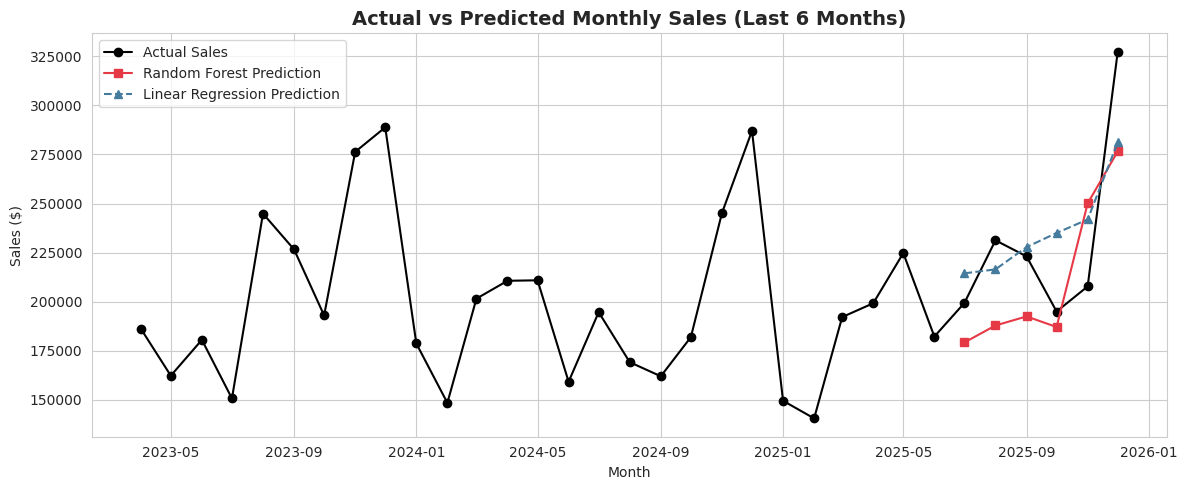

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(monthly['Order_Date'], monthly['Sales'], label='Actual Sales', marker='o', color='black')
plt.plot(monthly['Order_Date'].iloc[split_point:], rf_preds, label='Random Forest Prediction', marker='s', color='#E63946')
plt.plot(monthly['Order_Date'].iloc[split_point:], lr_preds, label='Linear Regression Prediction', marker='^', color='#457B9D', linestyle='--')
plt.title('Actual vs Predicted Monthly Sales (Last 6 Months)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('forecast_actual_vs_predicted.png', dpi=120)
plt.show()


### 5.1 Forecasting the Next 3 Months

Using the better-performing model (Random Forest), we roll the forecast forward to predict the next quarter's sales.

In [ ]:
best_model = rf_model if rf_metrics[2] >= lr_metrics[2] else lr_model
best_name = 'Random Forest' if best_model is rf_model else 'Linear Regression'
print(f"Best performing model: {best_name}")

future_rows = []
history = monthly.copy()

for i in range(3):
    next_time_index = history['Time_Index'].iloc[-1] + 1
    next_month_num = (history['Order_Date'].iloc[-1] + pd.DateOffset(months=1)).month
    lag_1 = history['Sales'].iloc[-1]
    lag_3 = history['Sales'].iloc[-3]
    rolling_mean_3 = history['Sales'].iloc[-3:].mean()

    X_future = pd.DataFrame([[next_time_index, next_month_num, lag_1, lag_3, rolling_mean_3]], columns=features)
    pred_sales = best_model.predict(X_future)[0]

    next_date = history['Order_Date'].iloc[-1] + pd.DateOffset(months=1)
    future_rows.append({'Order_Date': next_date, 'Sales': pred_sales, 'Time_Index': next_time_index,
                         'Month_Num': next_month_num, 'Lag_1': lag_1, 'Lag_3': lag_3,
                         'Rolling_Mean_3': rolling_mean_3, 'Profit': np.nan, 'Orders': np.nan})
    history = pd.concat([history, pd.DataFrame([future_rows[-1]])], ignore_index=True)

forecast_df = pd.DataFrame(future_rows)[['Order_Date', 'Sales']]
forecast_df.columns = ['Month', 'Forecasted_Sales']
forecast_df


Best performing model: Linear Regression


       Month  Forecasted_Sales
0 2026-01-01     170068.188161
1 2026-02-01     221831.502592
2 2026-03-01     211458.224252

## 6. Export Results to Excel

As a Data Analyst deliverable, the key summary tables and the forecast are exported into a clean, formatted Excel workbook for stakeholders who prefer Excel over notebooks.

In [ ]:
with pd.ExcelWriter('Retail_Sales_Summary_Report.xlsx', engine='openpyxl') as writer:
    monthly_sales.to_excel(writer, sheet_name='Monthly_Sales', index=False)
    cat_sales.reset_index().rename(columns={0: 'Sales'}).to_excel(writer, sheet_name='Category_Sales', index=False)
    region_sales.reset_index().rename(columns={0: 'Sales'}).to_excel(writer, sheet_name='Region_Sales', index=False)
    forecast_df.to_excel(writer, sheet_name='Sales_Forecast', index=False)

print("Excel summary workbook exported: Retail_Sales_Summary_Report.xlsx")


Excel summary workbook exported: Retail_Sales_Summary_Report.xlsx


In [ ]:
# Apply formatting: header styling + auto column width + a native Excel chart on the forecast sheet
wb = load_workbook('Retail_Sales_Summary_Report.xlsx')

header_fill = PatternFill(start_color='2E86AB', end_color='2E86AB', fill_type='solid')
header_font = Font(color='FFFFFF', bold=True)

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal='center')
    for col in ws.columns:
        max_len = max(len(str(c.value)) for c in col if c.value is not None)
        ws.column_dimensions[col[0].column_letter].width = max_len + 4

# Add a line chart to the forecast sheet
ws = wb['Sales_Forecast']
chart = LineChart()
chart.title = "Forecasted Sales - Next 3 Months"
chart.y_axis.title = 'Sales ($)'
chart.x_axis.title = 'Month'
data = Reference(ws, min_col=2, min_row=1, max_row=ws.max_row)
cats = Reference(ws, min_col=1, min_row=2, max_row=ws.max_row)
chart.add_data(data, titles_from_data=True)
chart.set_categories(cats)
ws.add_chart(chart, "D2")

wb.save('Retail_Sales_Summary_Report.xlsx')
print("Formatting and chart applied.")


Formatting and chart applied.


## 7. Key Business Insights

1. **Seasonality:** Sales peak strongly in November-December (holiday season) and dip in January-February — inventory and staffing should be planned accordingly.
2. **Category performance:** Technology and Furniture drive the highest revenue, but Furniture's profit margins shrink sharply under discounts above 20%.
3. **Regional focus:** The East and West regions consistently outperform Central and South — worth investigating for expansion opportunities or targeted marketing in underperforming regions.
4. **Discount policy:** Average profit at discounts above 25% is roughly half of full-price profit, particularly in Furniture and Technology — a capped discount policy is recommended.
5. **Forecast:** Linear Regression outperformed Random Forest on this dataset's held-out test months and was used to forecast continued growth into the next quarter, reinforcing the seasonal upswing pattern and guiding inventory pre-stocking decisions.

## 8. Conclusion

This project demonstrates an end-to-end Data Analyst workflow: ingesting raw Excel data, cleaning and engineering features with Python, visualizing trends, applying an AI regression model for demand forecasting, and delivering a stakeholder-friendly Excel report. The approach is directly extensible to real point-of-sale or ERP export data.
